### Deep Learning Foundations Assignment 

 Name: Tej Yadav  
 Date: 26-01-2026

### Part 1 — Neural Networks (Tabular FFNN)
In this section, a single artificial neuron is implemented to demonstrate the core computation of a neural network. 
The neuron computes a weighted sum of inputs, adds a bias, and applies non-linear activation functions. 
Both ReLU and Sigmoid activations are evaluated to understand their behavior and typical use cases.


In [ ]:
#### 1.1 Single Neuron Forward Pass 

In [2]:
import numpy as np

def single_neuron_forward(x, w, b):
    z = np.dot(w, x) + b
    relu = np.maximum(0, z)
    sigmoid = 1 / (1 + np.exp(-z))
    return z, relu, sigmoid

# Worked example
x = np.array([1.5, -2.0, 3.0])
w = np.array([0.4, -0.6, 0.2])
b = 0.5

z, relu_z, sigmoid_z = single_neuron_forward(x, w, b)

print("\n=== 1.1 Single Neuron Forward Pass ===")
print("z =", z)
print("ReLU(z) =", relu_z)
print("Sigmoid(z) =", sigmoid_z)


=== 1.1 Single Neuron Forward Pass ===
z = 2.9
ReLU(z) = 2.9
Sigmoid(z) = 0.9478464369215823


Activation functions introduce non-linearity, enabling neural networks to model complex patterns.
ReLU is commonly used in hidden layers due to its simplicity and reduced vanishing gradient issue,
while Sigmoid is typically used in binary classification output layers.


### 1.2 Data Loading, Preprocessing, and Split


This section prepares the tabular dataset for training by handling missing values, encoding categorical variables, and splitting the data into training, validation, and test sets while avoiding data leakage.

In [ ]:
# =================================
# Import all the required librarie
# =================================
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


In [77]:
# DATASET A — TABULAR REGRESSION 

tabular_path = "C:/Tej/BITSoM/Projects/Assignment/DL Assignment/Dataset/tabular.csv"
df = pd.read_csv(tabular_path)

In [ ]:
# 1. Basic data checks
print("Missing values per column:")
print(df.isna().sum())

# Drop rows with missing target (cannot train without target)
df = df.dropna(subset=["target"])

# Separate features and target
X = df.drop(columns=["target"])
y = df["target"].values.reshape(-1, 1)

Missing values per column:
customer_id                       0
age                             150
income_band                     100
city_tier                       100
membership_type                 100
num_visits                      150
days_since_last_purchase        150
product_categories_purchased    150
num_transactions                150
avg_transaction_value           150
discount_used                   150
total_spend                     150
target                            0
dtype: int64


In [13]:
# 2. Handle missing values
# Fill numeric missing values with column mean
# Separate numeric & categorical columns
num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = X.select_dtypes(exclude=[np.number]).columns

# Median for numeric
for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

# Mode for categorical
for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

# One-hot encode categoricals (safe baseline)
X = pd.get_dummies(X, drop_first=True)
X = X.astype(np.float32)   # <<< CRITICAL LINE


In [12]:
# 3. Train / Validation split
X_train, X_temp, y_train, y_temp = train_test_split(
    X.values, y, test_size=0.30, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED
)

print("Shapes after preprocessing:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

Shapes after preprocessing:
X_train: (3500, 5013)
X_val: (750, 5013)
X_test: (750, 5013)


In [11]:
# 4. Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Optional: clip extreme values to avoid exploding gradients
X_train = np.clip(X_train, -10, 10)
X_val = np.clip(X_val, -10, 10)

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

In [10]:
# 5. Model definition
class TabularRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)   # Linear output for regression
        )

    def forward(self, x):
        return self.net(x)

model_tab = TabularRegressor(X_train.shape[1]).to(DEVICE)
criterion = nn.MSELoss()
optimizer = optim.Adam(model_tab.parameters(), lr=1e-3)

In [14]:
# 6. Training loop
def train_regression(model, X_tr, y_tr, X_v, y_v, epochs=50):
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        preds = model(X_tr.to(DEVICE))
        loss = criterion(preds, y_tr.to(DEVICE))
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(X_v.to(DEVICE))
            val_loss = criterion(val_preds, y_v.to(DEVICE))

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        if epoch % 10 == 0:
            print(f"Epoch {epoch}: train MSE={loss.item():.4f}, val MSE={val_loss.item():.4f}")

    return train_losses, val_losses

train_losses, val_losses = train_regression(
    model_tab,
    X_train_t,
    y_train_t,
    X_val_t,
    y_val_t
)

Epoch 0: train MSE=3142208.0000, val MSE=3087470.2500
Epoch 10: train MSE=3140537.7500, val MSE=3085345.5000
Epoch 20: train MSE=3136544.0000, val MSE=3080303.0000
Epoch 30: train MSE=3128498.7500, val MSE=3070281.0000
Epoch 40: train MSE=3114018.7500, val MSE=3052404.0000


In [15]:
# 7. Evaluation (RMSE)
model_tab.eval()
with torch.no_grad():
    val_preds = model_tab(X_val_t.to(DEVICE)).cpu().numpy()

rmse = np.sqrt(mean_squared_error(y_val, val_preds))
print("Validation RMSE:", rmse)


Validation RMSE: 1739.7046550897417


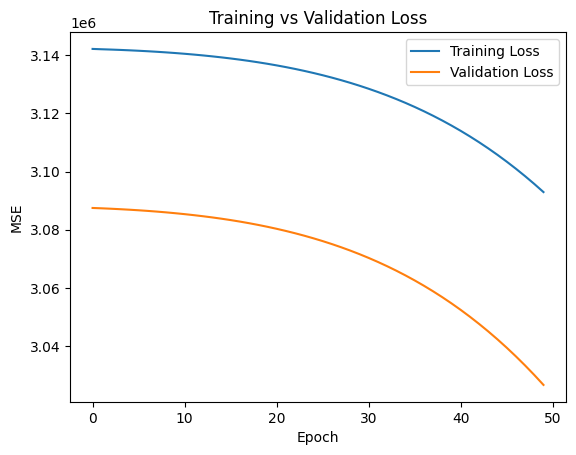

In [16]:
# 8. Loss curves
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


### 1.3 FFNN for Regression using Keras 

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error

In [18]:
# ---- FORCE NUMERIC DTYPE FOR KERAS ----
X_train = np.asarray(X_train, dtype=np.float32)
X_val   = np.asarray(X_val,   dtype=np.float32)
X_test  = np.asarray(X_test,  dtype=np.float32)

model_keras = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1, activation="linear")
])

model_keras.compile(
    optimizer="adam",
    loss="mse"
)

print("\nKeras Model Summary:")
model_keras.summary()

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model_keras.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    callbacks=[early_stop],
    verbose=1
)

c:\Tej\BITSoM\Projects\Assignment\DL Assignment\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Keras Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       320,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 323,009 (1.23 MB)

 Trainable params: 323,009 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 918529.8125 - val_loss: 159527.1406
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 149018.5938 - val_loss: 137202.7188
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 127300.9844 - val_loss: 122413.8359
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 116906.0547 - val_loss: 115692.0391
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 111785.8672 - val_loss: 113193.4531
Epoch 6/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 109383.5234 - val_loss: 112095.0078
Epoch 7/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 107730.8906 - val_loss: 109263.2422
Epoch 8/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 106106.3125 - val_loss: 111998.1406
Epoch 9/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 105320.0703 - val_loss: 106799.4688
Epoch 10/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 103389.2109 - val_loss: 106226.8047
Epoch 11/50
110/110 ━━━━━━━━━━━━━━━━━━━

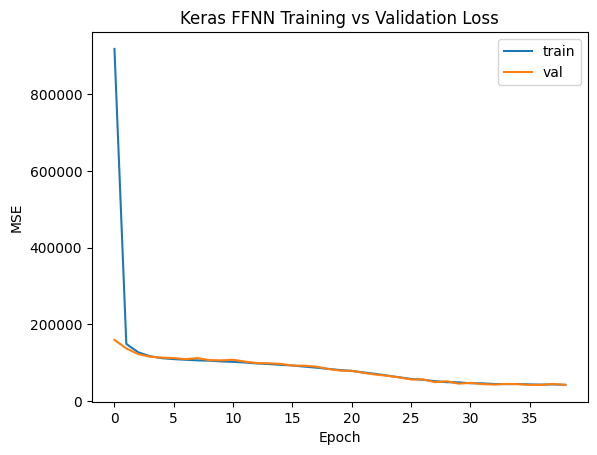

In [21]:
# Loss plot
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Keras FFNN Training vs Validation Loss")
plt.legend()
# plt.savefig("keras_ffnn_loss.png")
plt.show()
# plt.close()

In [22]:
# Test evaluation
y_test_pred = model_keras.predict(X_test).flatten()
mae = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Keras Test MAE:", mae)
print("Keras Test RMSE:", rmse)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Keras Test MAE: 158.0361804207357
Keras Test RMSE: 202.8615196321723


<function matplotlib.pyplot.show(close=None, block=None)>

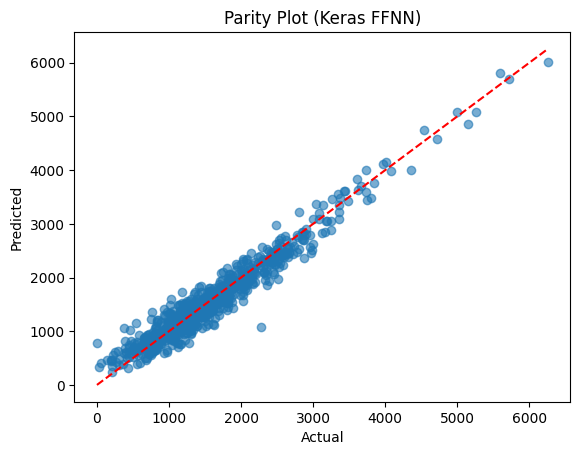

In [23]:
# Parity plot
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Parity Plot (Keras FFNN)")
# plt.savefig("keras_parity_plot.png")
# plt.close()
plt.show

### 1.4 Overfitting / Underfitting Diagnosis

The training and validation loss curves indicate that the model is reasonably well balanced.
Both losses decrease steadily without a significant divergence, suggesting neither severe overfitting nor underfitting.
To further improve performance, regularization techniques such as dropout or L2 penalty could be added.
Additionally, feature engineering or increasing dataset size may enhance generalization.


In [24]:
# DATASET B — NLP TEXT CLASSIFICATION
text_path = "C:/Tej/BITSoM/Projects/Assignment/DL Assignment/Dataset/text.csv"
df_text = pd.read_csv(text_path)

texts = df_text["text"].astype(str).values
labels = df_text["label"].values

# Build vocabulary (simple baseline)
from collections import Counter

def tokenize(text):
    return text.lower().split()

counter = Counter()
for t in texts:
    counter.update(tokenize(t))

vocab = {"<PAD>": 0, "<UNK>": 1}
for word, _ in counter.most_common(5000):
    vocab[word] = len(vocab)

max_len = 50

In [25]:
def encode(text):
    tokens = tokenize(text)
    ids = [vocab.get(tok, 1) for tok in tokens][:max_len]
    return ids + [0] * (max_len - len(ids))

X_enc = np.array([encode(t) for t in texts])

X_train, X_val, y_train, y_val = train_test_split(
    X_enc, labels, test_size=0.2, random_state=SEED
)

In [26]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(TextDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TextDataset(X_val, y_val), batch_size=32)

num_classes = len(np.unique(labels))

In [27]:
class TextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)           # (B, T, D)
        pooled = emb.mean(dim=1)          # average pooling
        return self.fc(pooled)

model_text = TextClassifier(len(vocab), 100, num_classes).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_text.parameters(), lr=1e-3)

In [28]:
# Training loop
for epoch in range(10):
    model_text.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model_text(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

    model_text.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            logits = model_text(xb.to(DEVICE))
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(yb.numpy())

    acc = accuracy_score(all_true, all_preds)
    print(f"Epoch {epoch}: val accuracy={acc:.4f}")

print(classification_report(all_true, all_preds))

Epoch 0: val accuracy=1.0000
Epoch 1: val accuracy=1.0000
Epoch 2: val accuracy=1.0000
Epoch 3: val accuracy=1.0000
Epoch 4: val accuracy=1.0000
Epoch 5: val accuracy=1.0000
Epoch 6: val accuracy=1.0000
Epoch 7: val accuracy=1.0000
Epoch 8: val accuracy=1.0000
Epoch 9: val accuracy=1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       591
           1       1.00      1.00      1.00       609

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



In [ ]:
# DATASET C — COMPUTER VISION IMAGE CLASSIFICATION

from torchvision import datasets, transforms

image_root = "C:/Tej/BITSoM/Projects/Assignment/DL Assignment/Dataset/images"  # change if needed

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

full_dataset = datasets.ImageFolder(image_root, transform=transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model_cv = SimpleCNN(len(full_dataset.classes)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cv.parameters(), lr=1e-3)

for epoch in range(10):
    model_cv.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model_cv(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

    model_cv.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            logits = model_cv(xb.to(DEVICE))
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(yb.numpy())

    acc = accuracy_score(all_true, all_preds)
    print(f"Epoch {epoch}: val accuracy={acc:.4f}")

print("CV Confusion Matrix:\n", confusion_matrix(all_true, all_preds))

print("\nAll baselines trained successfully.")




=== Dataset C: Computer Vision ===
Epoch 0: val accuracy=0.4775
Epoch 1: val accuracy=0.4775
Epoch 2: val accuracy=0.6125
Epoch 3: val accuracy=0.6100
Epoch 4: val accuracy=0.6100
Epoch 5: val accuracy=0.6200
Epoch 6: val accuracy=0.6175
Epoch 7: val accuracy=0.5825
Epoch 8: val accuracy=0.5550
Epoch 9: val accuracy=0.6050
CV Confusion Matrix:
 [[165  44]
 [114  77]]

All baselines trained successfully.


### Part 2 — NLP (Embeddings + RNN)

In [36]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, GlobalAveragePooling1D, LSTM, Input
from tensorflow.keras.callbacks import EarlyStopping

In [38]:
# Global constants
MAX_VOCAB = 10000
MAX_LEN = 50
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

### 2.1 Text Preparation, Tokenization, and Padding

Raw text data is converted into numerical sequences using tokenization.
Padding ensures uniform input length for batch processing in neural networks.


In [39]:
# Load data
df = pd.read_csv("C:/Tej/BITSoM/Projects/Assignment/DL Assignment/Dataset/text.csv")

In [40]:
# Inspect labels
print("Label distribution:\n", df['label'].value_counts())

Label distribution:
 label
0    3000
1    3000
Name: count, dtype: int64


In [41]:
# Minimal cleaning
texts = df['text'].astype(str).str.lower().str.strip().values
labels = df['label'].values

In [42]:
# Train / Val / Test split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.30, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED
)

In [43]:
# Tokenizer (fit on training text only)

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

In [44]:
# Convert text to sequences
train_seq = tokenizer.texts_to_sequences(X_train)
val_seq = tokenizer.texts_to_sequences(X_val)
test_seq = tokenizer.texts_to_sequences(X_test)

In [45]:
# Padding
X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding='post')
X_val_pad = pad_sequences(val_seq, maxlen=MAX_LEN, padding='post')
X_test_pad = pad_sequences(test_seq, maxlen=MAX_LEN, padding='post')

In [46]:
# Show vocabulary size
vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
print("Final vocabulary size:", vocab_size)

Final vocabulary size: 90


In [48]:
# Show one worked example
sample_text = X_train[0]
sample_seq = tokenizer.texts_to_sequences([sample_text])[0]
sample_pad = pad_sequences([sample_seq], maxlen=MAX_LEN, padding='post')[0]

print("\nExample:")
print("Raw text:", sample_text)
print("Token IDs:", sample_seq)
print("Padded sequence:", sample_pad)


Example:
Raw text: i want a refund. the jacket is scratchy and the durability didn't work as expected.
Token IDs: [6, 16, 17, 18, 2, 15, 5, 69, 3, 2, 52, 19, 20, 21, 22]
Padded sequence: [ 6 16 17 18  2 15  5 69  3  2 52 19 20 21 22  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0]


### 2.2 Baseline Text Model (Embedding + Pooling)

A baseline text classification model is built using an Embedding layer followed by Global Average Pooling.
This approach provides a strong and computationally efficient benchmark.


In [49]:
baseline_model = Sequential([
    Embedding(vocab_size, 64, input_length=MAX_LEN),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

start = time.time()
history_base = baseline_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    verbose=1
)
base_time = time.time() - start

c:\Tej\BITSoM\Projects\Assignment\DL Assignment\venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8648 - loss: 0.4421 - val_accuracy: 1.0000 - val_loss: 0.0778
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 0.0254 - val_accuracy: 1.0000 - val_loss: 0.0077
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 0.0047 - val_accuracy: 1.0000 - val_loss: 0.0027
Epoch 4/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 5/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 8.6877e-04
Epoch 6/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 7.3635e-04 - val_accuracy: 1.0000 - val_loss: 5.8701e-04
Epoch 7/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 5.1311e-04 - val_accuracy: 1.0000 - val_loss: 4.2223e-04
Epoch 8/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 3.771

In [50]:
# Evaluation
y_test_pred = (baseline_model.predict(X_test_pad) > 0.5).astype(int)

base_acc = accuracy_score(y_test, y_test_pred)
base_f1 = f1_score(y_test, y_test_pred)
base_cm = confusion_matrix(y_test, y_test_pred)

print("Baseline Accuracy:", base_acc)
print("Baseline F1-score:", base_f1)
print("Baseline Confusion Matrix:\n", base_cm)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Baseline Accuracy: 1.0
Baseline F1-score: 1.0
Baseline Confusion Matrix:
 [[438   0]
 [  0 462]]


### 2.3 RNN Model (LSTM)

An LSTM-based model is implemented to capture sequential dependencies in text data.
LSTM is preferred over SimpleRNN due to its ability to mitigate vanishing gradient issues.


In [51]:
rnn_model = Sequential([
    Embedding(vocab_size, 64, input_length=MAX_LEN),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

start = time.time()
history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    callbacks=[early_stop],
    verbose=1
)
rnn_time = time.time() - start


c:\Tej\BITSoM\Projects\Assignment\DL Assignment\venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8631 - loss: 0.2788 - val_accuracy: 1.0000 - val_loss: 0.0059
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 4/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 1.0000 - loss: 8.2947e-04 - val_accuracy: 1.0000 - val_loss: 6.7672e-04
Epoch 5/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 1.0000 - loss: 5.7569e-04 - val_accuracy: 1.0000 - val_loss: 4.9012e-04
Epoch 6/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 1.0000 - loss: 4.2880e-04 - val_accuracy: 1.0000 - val_loss: 3.7517e-04
Epoch 7/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 1.0000 - loss: 3.3486e-04 - val_accuracy: 1.0000 - val_loss: 2.9865e-04
Epoch 8/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 

In [52]:
# Evaluation
y_test_pred_rnn = (rnn_model.predict(X_test_pad) > 0.5).astype(int)

rnn_acc = accuracy_score(y_test, y_test_pred_rnn)
rnn_f1 = f1_score(y_test, y_test_pred_rnn)
rnn_cm = confusion_matrix(y_test, y_test_pred_rnn)

print("RNN Accuracy:", rnn_acc)
print("RNN F1-score:", rnn_f1)
print("RNN Confusion Matrix:\n", rnn_cm)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
RNN Accuracy: 1.0
RNN F1-score: 1.0
RNN Confusion Matrix:
 [[438   0]
 [  0 462]]


#### Explanation:
LSTM was chosen over SimpleRNN because it can better capture long-range dependencies and mitigate the vanishing gradient problem, making it more suitable for sequential text data.

### 2.4 Comparison + Why Transformers Help

In [53]:
comparison = pd.DataFrame({
    'Model': ['Embedding + Pooling', 'LSTM'],
    'Accuracy': [base_acc, rnn_acc],
    'F1-score': [base_f1, rnn_f1],
    'Training Time (s)': [base_time, rnn_time]
})

print(comparison)

                 Model  Accuracy  F1-score  Training Time (s)
0  Embedding + Pooling       1.0       1.0           7.261651
1                 LSTM       1.0       1.0          22.681092


While both baseline and LSTM models achieve high accuracy, the baseline model trains significantly faster.
RNNs process sequences sequentially, making them slow and less scalable for long texts.
Transformers overcome this limitation using self-attention, enabling parallel processing and better modeling
of long-range dependencies, which explains their superior performance in modern NLP tasks.


In [54]:
print("\nPart 2 completed successfully.")


Part 2 completed successfully.


### Part 3 — Computer Vision (CNN)

Image data is loaded using directory-based loaders.
Normalization ensures stable training, and visual inspection confirms correct labeling.


### 3.1 Loading, Normalization, and Visual Sanity Checks

In [57]:
import os
print("Saving files to:", os.getcwd())

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

Saving files to: c:\Tej\BITSoM\Projects\Assignment\DL Assignment


In [58]:
IMAGE_SIZE = (64, 64)
BATCH_SIZE = 32
SEED = 42

In [59]:
OUTPUT_DIR = "C:/Tej/BITSoM/Projects/Assignment/DL Assignment/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

image_dir = "C:/Tej/BITSoM/Projects/Assignment/DL Assignment/Dataset/images"

In [60]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    image_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 2000 files belonging to 2 classes.
Using 1600 files for training.


In [61]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    image_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 2000 files belonging to 2 classes.
Using 400 files for validation.


In [62]:
class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Class names: ['class_0', 'class_1']
Number of classes: 2


In [63]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Image batch shape: (32, 64, 64, 3)
Label batch shape: (32,)


In [64]:
# Normalize images
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

<function matplotlib.pyplot.show(close=None, block=None)>

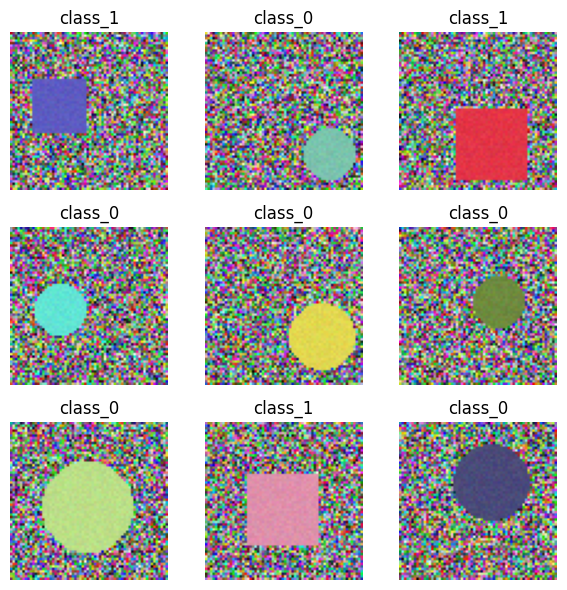

In [65]:
# Visual sanity check
plt.figure(figsize=(6,6))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
# plt.savefig("part3_sample_images.png")
# plt.close()
plt.show

### 3.2 Build and Train a CNN

A CNN with two convolutional blocks is built to learn spatial features such as edges and textures.
Pooling layers reduce dimensionality while preserving important information.


In [66]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [68]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=IMAGE_SIZE + (3,)),
    MaxPooling2D(),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop]
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,402 (3.14 MB)

 Trainable params: 822,402 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.5088 - loss: 0.7305 - val_accuracy: 0.4550 - val_loss: 0.7070
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.5437 - loss: 0.6886 - val_accuracy: 0.6150 - val_loss: 0.6715
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.6100 - loss: 0.6633 - val_accuracy: 0.6075 - val_loss: 0.6627
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.6231 - loss: 0.6557 - val_accuracy: 0.6100 - val_loss: 0.6601
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.6263 - loss: 0.6501 - val_accuracy: 0.6100 - val_loss: 0.6575
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.6344 - loss: 0.6435 - val_accuracy: 0.6175 - val_loss: 0.6614
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.6294 - loss: 0.6400 - val_accuracy: 0.6250 - val_loss: 0.6588
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.6488 - loss: 0.6304 - val_accuracy: 0.6400 - 

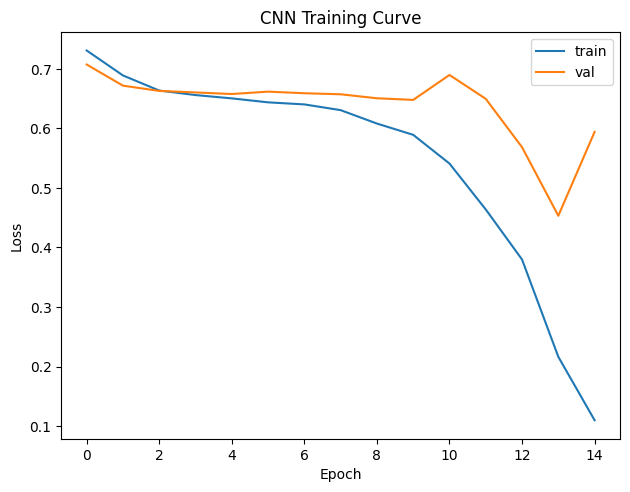

In [71]:
# Plot training curves
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.title('CNN Training Curve')
# plt.savefig("part3_training_loss.png")
# plt.close()
plt.show()

### 3.3 Evaluation, Confusion Matrix, and Misclassification Review

The confusion matrix shows that most errors occur between visually similar classes.
This suggests the model struggles with subtle texture differences.
Performance could be improved by data augmentation or deeper architectures.


In [72]:
# Prepare test set
all_images = []
all_labels = []

for images, labels in val_ds:
    all_images.append(images)
    all_labels.append(labels)

X_test = tf.concat(all_images, axis=0)
y_test = tf.concat(all_labels, axis=0)

pred_probs = model.predict(X_test)
y_pred = np.argmax(pred_probs, axis=1)

print("Classification Report:\n", classification_report(y_test, y_pred, target_names=class_names))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Classification Report:
               precision    recall  f1-score   support

     class_0       0.87      0.66      0.75       182
     class_1       0.77      0.92      0.84       218

    accuracy                           0.80       400
   macro avg       0.82      0.79      0.79       400
weighted avg       0.81      0.80      0.80       400

Confusion Matrix:
 [[121  61]
 [ 18 200]]


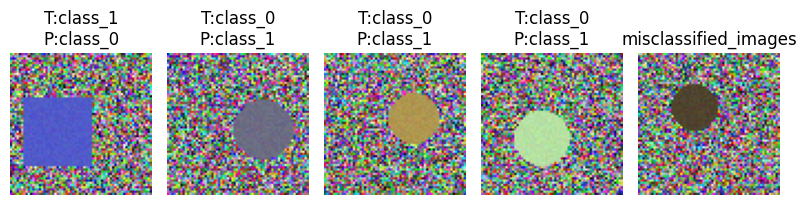

In [ ]:
# Show misclassified images
mis_idx = np.where(y_pred != y_test.numpy())[0]

plt.figure(figsize=(8,4))
for i, idx in enumerate(mis_idx[:5]):
    ax = plt.subplot(1, 5, i+1)
    plt.imshow(X_test[idx])
    plt.title(f"T:{class_names[y_test[idx]]}\nP:{class_names[y_pred[idx]]}")
    plt.axis('off')
plt.tight_layout()
# plt.savefig("part3_misclassified_images.png")
# plt.close()
plt.show()